Upload your Google Play Store CSV file


Saving googleplaystore.csv to googleplaystore.csv
Uploaded: googleplaystore.csv

Dataset Loaded Successfully
Shape: (10841, 13)

First 5 Rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



Data Preparation Completed
Final Shape: (8892, 13)


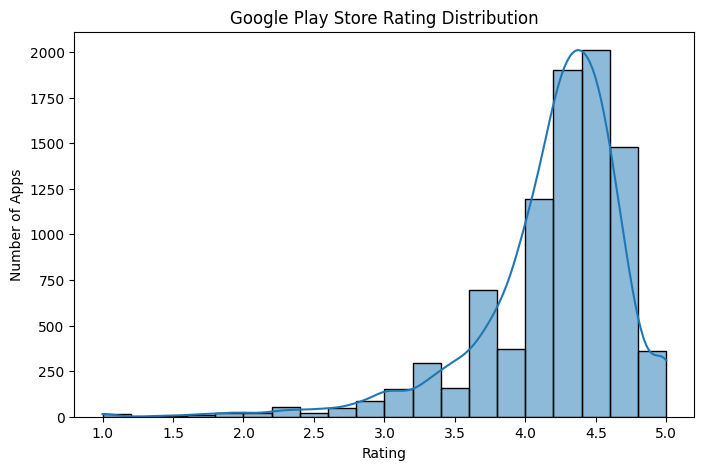

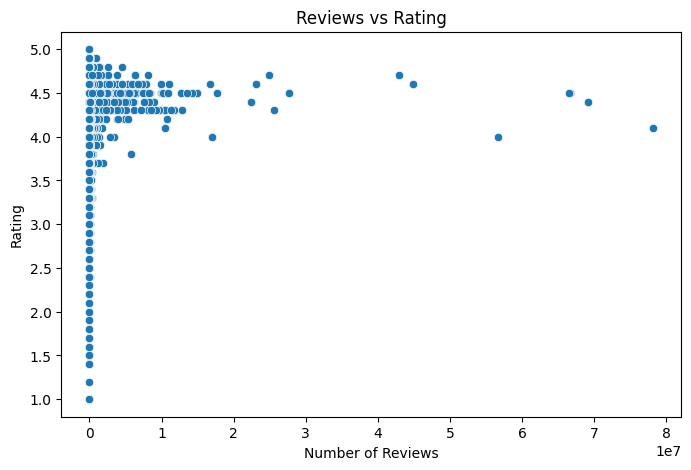

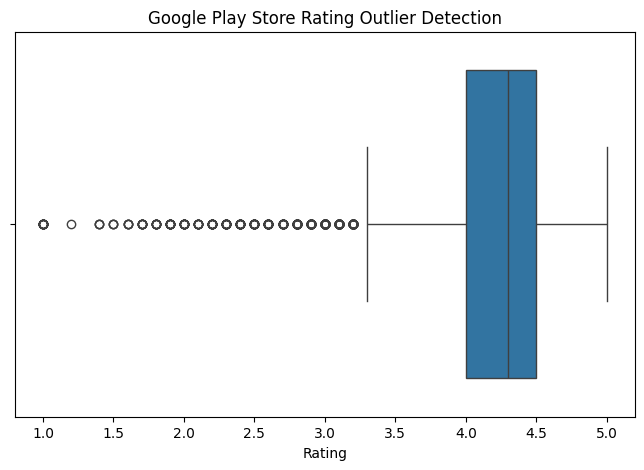

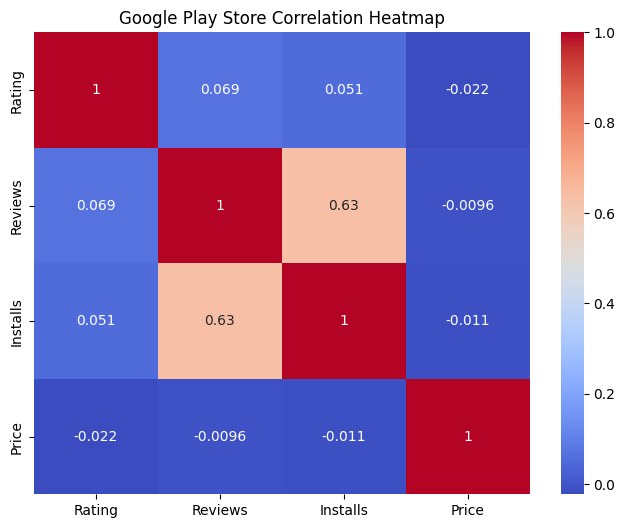

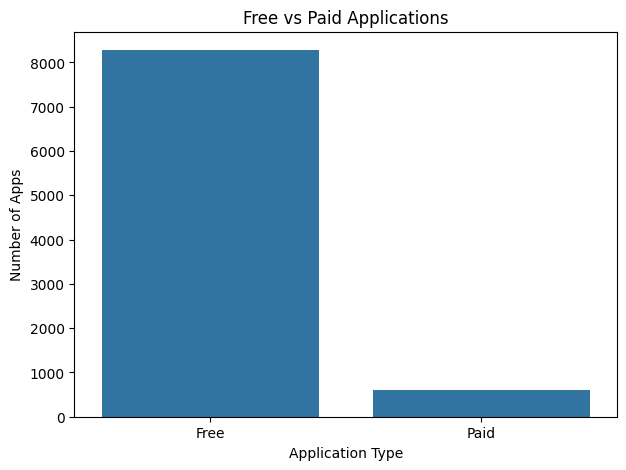

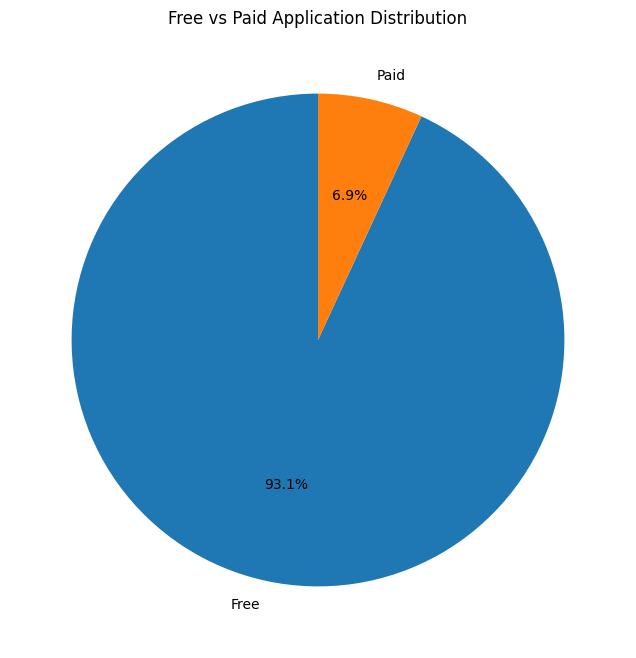

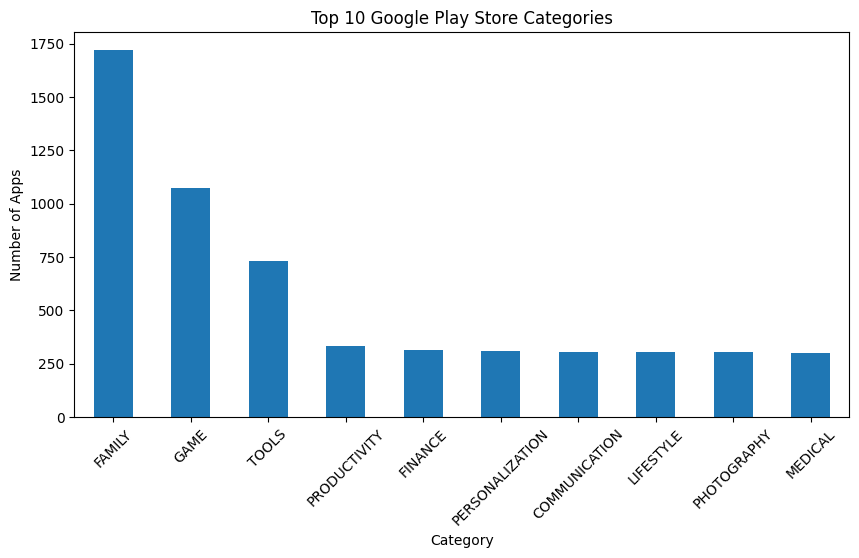

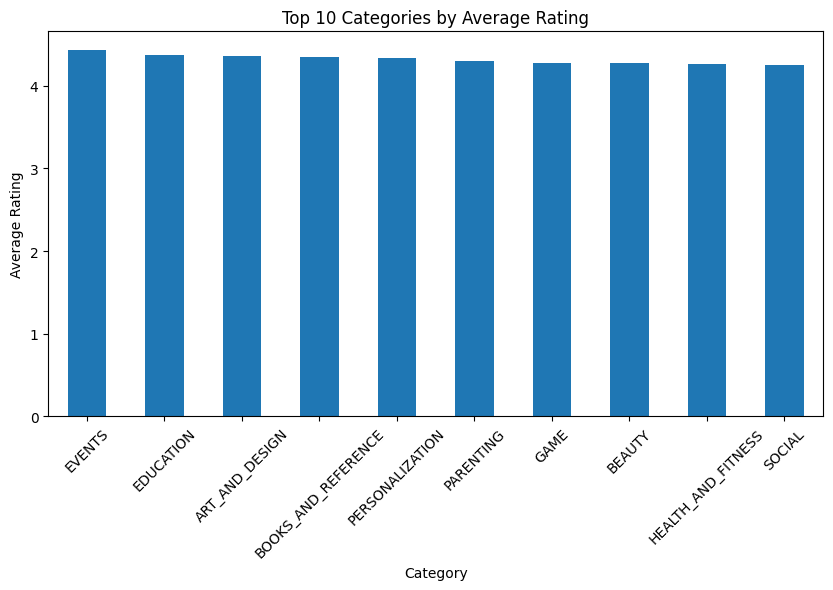

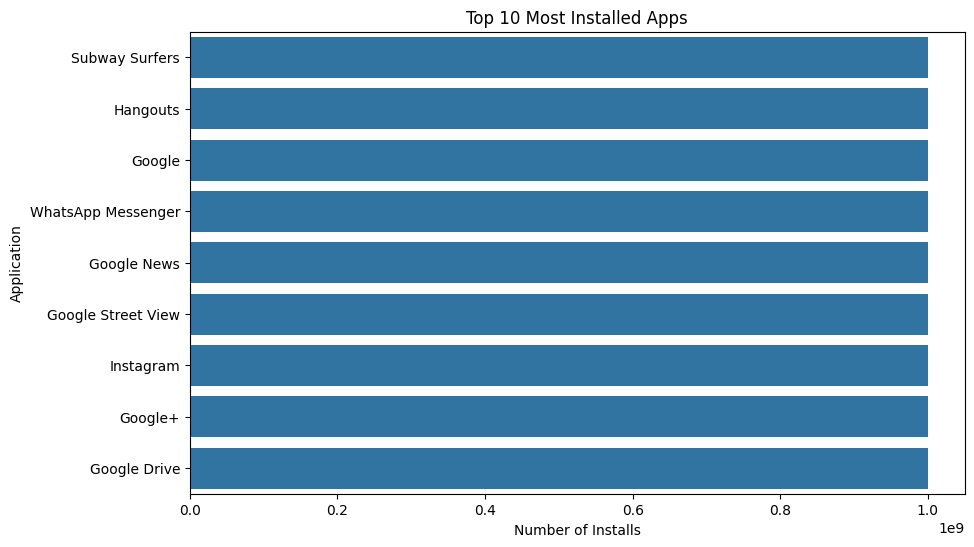

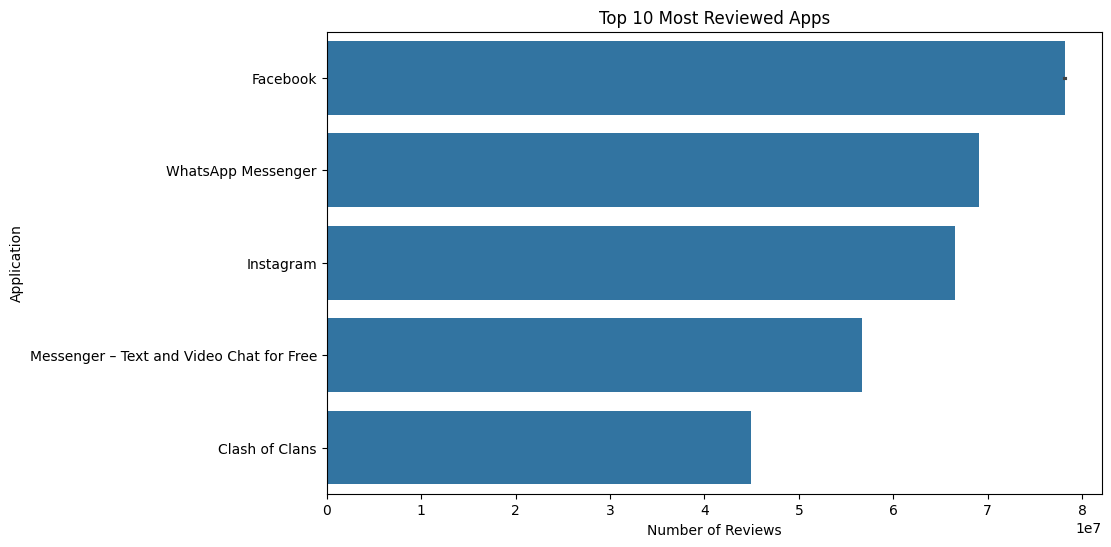

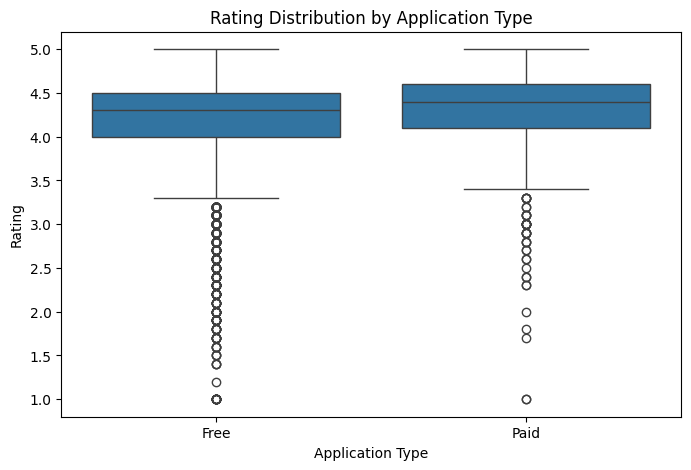

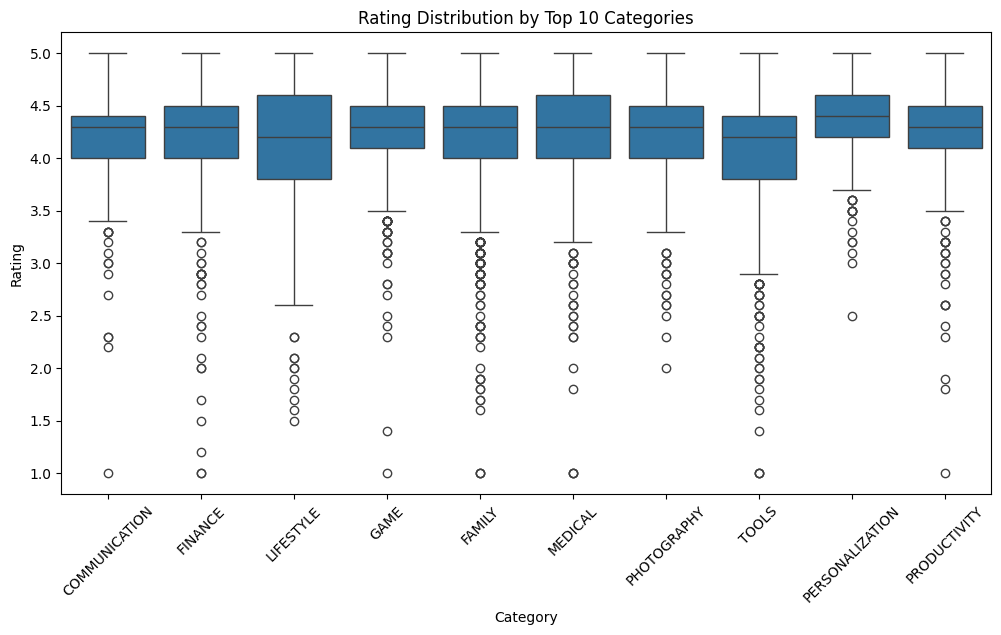

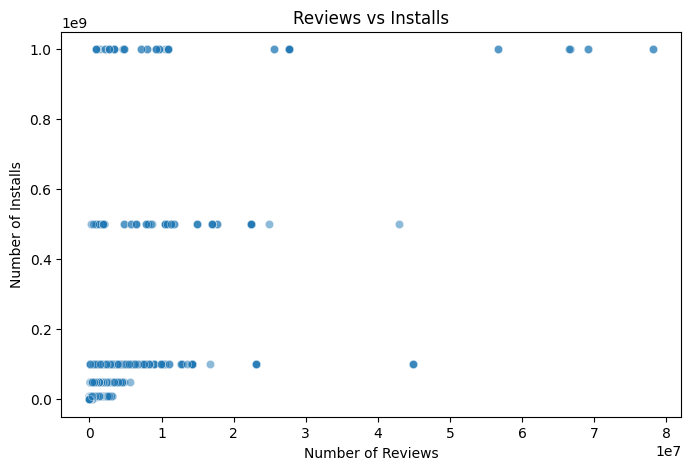

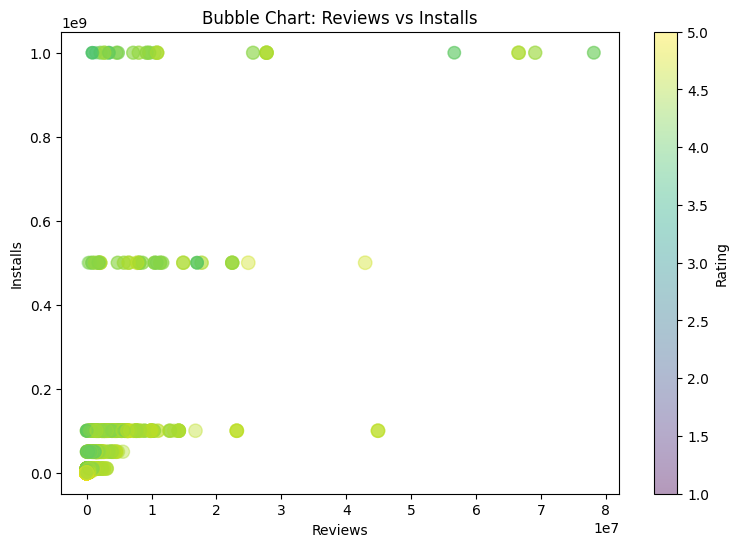

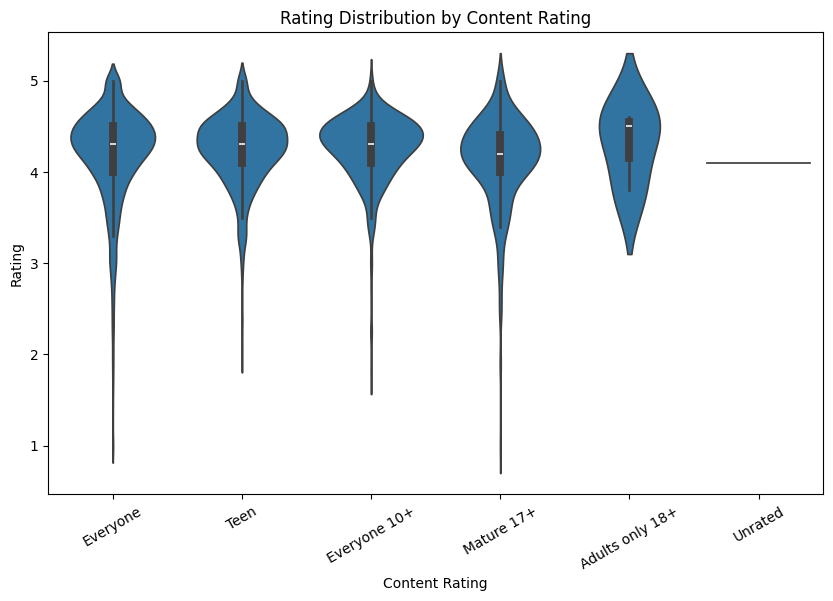

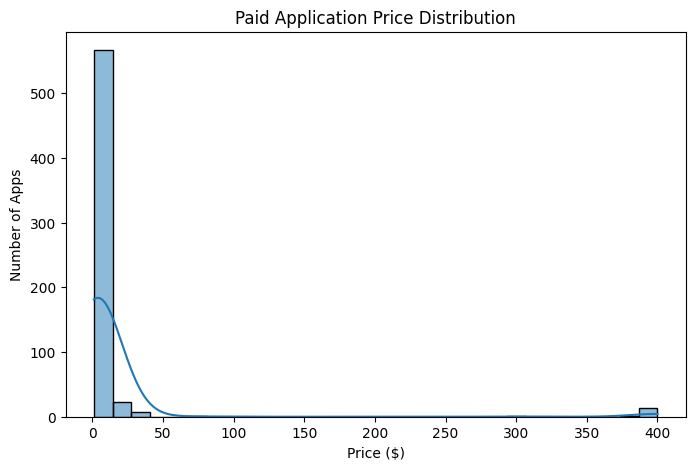

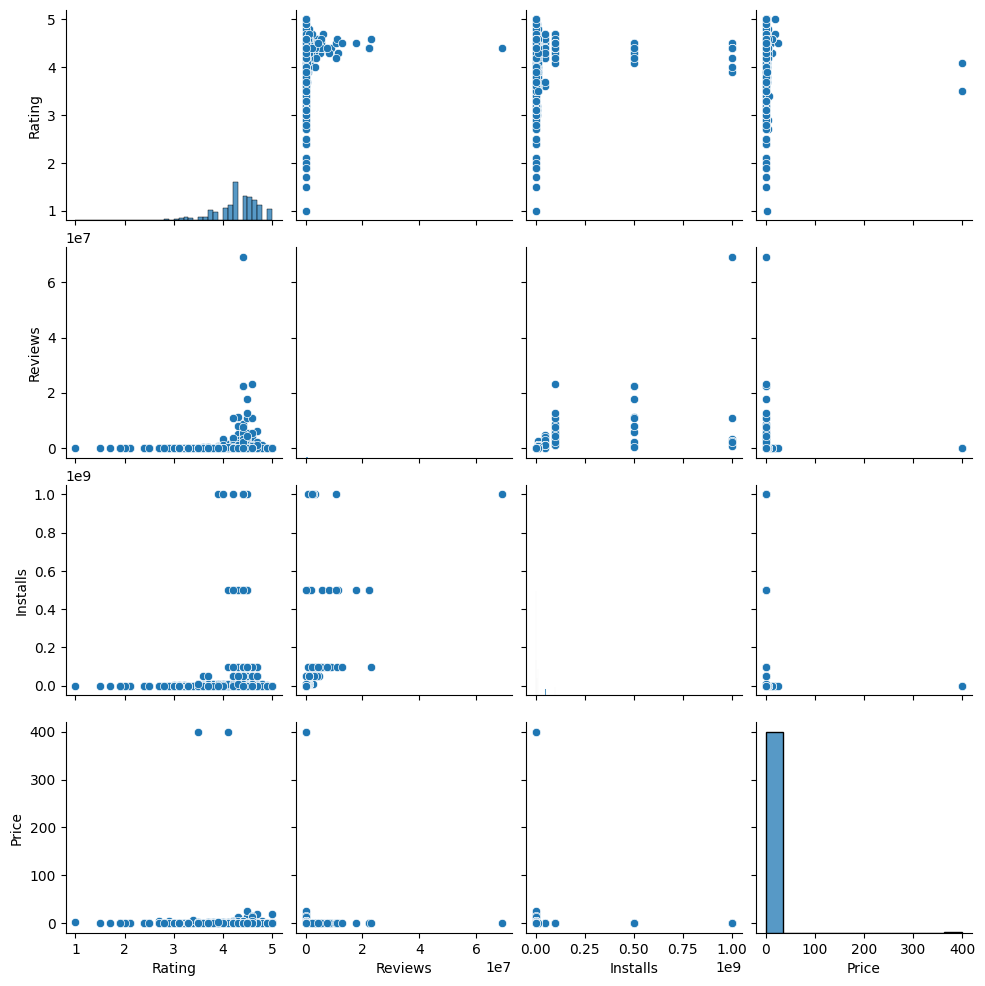



GOOGLE PLAY STORE VISUALIZATION COMPLETED

Total Applications: 8892
Average Rating: 4.19
Highest Rating: 5.0
Lowest Rating: 1.0
Free Applications: 8279
Paid Applications: 613
Number of Categories: 33
Most Common Category: FAMILY

Top 5 Most Installed Apps:
                     App      Installs
3896      Subway Surfers  1.000000e+09
4153            Hangouts  1.000000e+09
4150              Google  1.000000e+09
3904  WhatsApp Messenger  1.000000e+09
3816         Google News  1.000000e+09

EXPERIMENT FINISHED SUCCESSFULLY


In [1]:
# ============================================================
# GOOGLE PLAY STORE ANALYSIS
# DATA VISUALIZATION / ADVANCED EDA
# SINGLE CODE — GOOGLE COLAB
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files


# ============================================================
# 1. UPLOAD DATASET
# ============================================================

print("Upload your Google Play Store CSV file")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Uploaded:", filename)


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(filename)

print("\nDataset Loaded Successfully")
print("Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())


# ============================================================
# 3. DATA PREPARATION
# ============================================================

# Convert Rating
df["Rating"] = pd.to_numeric(
    df["Rating"],
    errors="coerce"
)

# Convert Reviews
df["Reviews"] = pd.to_numeric(
    df["Reviews"],
    errors="coerce"
)

# Convert Installs
df["Installs"] = pd.to_numeric(
    df["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False),
    errors="coerce"
)

# Convert Price
df["Price"] = pd.to_numeric(
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False),
    errors="coerce"
)

# Remove invalid ratings
df = df[
    (df["Rating"] >= 1) &
    (df["Rating"] <= 5)
]

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\nData Preparation Completed")
print("Final Shape:", df.shape)


# ============================================================
# 4. RATING DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)

plt.title("Google Play Store Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()


# ============================================================
# 5. REVIEWS VS RATING
# ============================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Reviews",
    y="Rating"
)

plt.title("Reviews vs Rating")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.show()


# ============================================================
# 6. RATING OUTLIER DETECTION
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Rating"]
)

plt.title("Google Play Store Rating Outlier Detection")
plt.xlabel("Rating")

plt.show()


# ============================================================
# 7. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(8,6))

corr = df[
    [
        "Rating",
        "Reviews",
        "Installs",
        "Price"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Google Play Store Correlation Heatmap")

plt.show()


# ============================================================
# 8. FREE VS PAID APPLICATIONS
# ============================================================

type_count = df["Type"].value_counts()

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Type"
)

plt.title("Free vs Paid Applications")
plt.xlabel("Application Type")
plt.ylabel("Number of Apps")

plt.show()


# ============================================================
# 9. FREE VS PAID PIE CHART
# ============================================================

plt.figure(figsize=(8,8))

plt.pie(
    type_count,
    labels=type_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Free vs Paid Application Distribution")

plt.show()


# ============================================================
# 10. TOP 10 CATEGORIES
# ============================================================

category_count = (
    df["Category"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

category_count.plot(
    kind="bar"
)

plt.title("Top 10 Google Play Store Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.xticks(rotation=45)

plt.show()


# ============================================================
# 11. CATEGORY-WISE AVERAGE RATING
# ============================================================

category_rating = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

category_rating.plot(
    kind="bar"
)

plt.title(
    "Top 10 Categories by Average Rating"
)

plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()


# ============================================================
# 12. MOST INSTALLED APPS
# ============================================================

top_installed = (
    df.sort_values(
        by="Installs",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_installed,
    x="Installs",
    y="App"
)

plt.title("Top 10 Most Installed Apps")
plt.xlabel("Number of Installs")
plt.ylabel("Application")

plt.show()


# ============================================================
# 13. MOST REVIEWED APPS
# ============================================================

top_reviewed = (
    df.sort_values(
        by="Reviews",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_reviewed,
    x="Reviews",
    y="App"
)

plt.title("Top 10 Most Reviewed Apps")
plt.xlabel("Number of Reviews")
plt.ylabel("Application")

plt.show()


# ============================================================
# 14. RATING BY APPLICATION TYPE
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Type",
    y="Rating"
)

plt.title("Rating Distribution by Application Type")
plt.xlabel("Application Type")
plt.ylabel("Rating")

plt.show()


# ============================================================
# 15. RATING BY CATEGORY
# ============================================================

top_categories = (
    df["Category"]
    .value_counts()
    .head(10)
    .index
)

category_df = df[
    df["Category"].isin(top_categories)
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=category_df,
    x="Category",
    y="Rating"
)

plt.title(
    "Rating Distribution by Top 10 Categories"
)

plt.xlabel("Category")
plt.ylabel("Rating")

plt.xticks(rotation=45)

plt.show()


# ============================================================
# 16. REVIEWS VS INSTALLS
# ============================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Reviews",
    y="Installs",
    alpha=0.5
)

plt.title("Reviews vs Installs")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Installs")

plt.show()


# ============================================================
# 17. BUBBLE CHART
# ============================================================

bubble_df = df.dropna(
    subset=[
        "Reviews",
        "Installs",
        "Rating"
    ]
)

plt.figure(figsize=(9,6))

plt.scatter(
    bubble_df["Reviews"],
    bubble_df["Installs"],
    s=bubble_df["Rating"] * 20,
    alpha=0.4,
    c=bubble_df["Rating"],
    cmap="viridis"
)

plt.colorbar(
    label="Rating"
)

plt.xlabel("Reviews")
plt.ylabel("Installs")

plt.title(
    "Bubble Chart: Reviews vs Installs"
)

plt.show()


# ============================================================
# 18. APP RATING DISTRIBUTION BY CONTENT RATING
# ============================================================

top_content = (
    df["Content Rating"]
    .value_counts()
    .head(8)
    .index
)

content_df = df[
    df["Content Rating"].isin(top_content)
]

plt.figure(figsize=(10,6))

sns.violinplot(
    data=content_df,
    x="Content Rating",
    y="Rating"
)

plt.title(
    "Rating Distribution by Content Rating"
)

plt.xlabel("Content Rating")
plt.ylabel("Rating")

plt.xticks(rotation=30)

plt.show()


# ============================================================
# 19. PAID APP PRICE DISTRIBUTION
# ============================================================

paid_df = df[
    (df["Type"] == "Paid") &
    (df["Price"] > 0)
]

plt.figure(figsize=(8,5))

sns.histplot(
    paid_df["Price"],
    bins=30,
    kde=True
)

plt.title("Paid Application Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.show()


# ============================================================
# 20. MULTIVARIATE PAIRPLOT
# ============================================================

pair_df = df[
    [
        "Rating",
        "Reviews",
        "Installs",
        "Price"
    ]
].dropna()

# Use a sample so the graph remains fast in Colab
if len(pair_df) > 1000:
    pair_df = pair_df.sample(
        1000,
        random_state=42
    )

sns.pairplot(
    pair_df
)

plt.show()


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n")
print("====================================================")
print("GOOGLE PLAY STORE VISUALIZATION COMPLETED")
print("====================================================")

print(
    "\nTotal Applications:",
    len(df)
)

print(
    "Average Rating:",
    round(df["Rating"].mean(), 2)
)

print(
    "Highest Rating:",
    df["Rating"].max()
)

print(
    "Lowest Rating:",
    df["Rating"].min()
)

print(
    "Free Applications:",
    (df["Type"] == "Free").sum()
)

print(
    "Paid Applications:",
    (df["Type"] == "Paid").sum()
)

print(
    "Number of Categories:",
    df["Category"].nunique()
)

print(
    "Most Common Category:",
    df["Category"].mode()[0]
)

print("\nTop 5 Most Installed Apps:")

print(
    df.sort_values(
        "Installs",
        ascending=False
    )[["App", "Installs"]].head()
)

print("\n====================================================")
print("EXPERIMENT FINISHED SUCCESSFULLY")
print("====================================================")